# Experimental Nq (Flow Number) from the Tris-Base / HCl Titration Run

## What this notebook models
This is NOT a simple inert tracer pulse. This is a real Tris buffer preparation:
Tris base (pH 10.5) is titrated with HCl, fed **continuously** (110 mL/min, for
266 mL total => ~2.42 min feed duration) into Zone 1 (top), until the bulk
reaches pH 8.5. The measured pH follows the **Henderson-Hasselbalch (HH)**
equation, not a simple exponential dilution curve:

$$ pH = pK_a + \log_{10}\!\left(\frac{[\text{Tris}]}{[\text{TrisH}^+]}\right) $$

The acid-base proton transfer itself is effectively instantaneous (diffusion-limited,
~10^10 L/mol/s) compared to mixing timescales (seconds-minutes) - so the ONLY thing
slowing down the pH transition is how fast the added H+ gets mixed/circulated
through the vessel. That circulation rate is exactly the unknown we want (Q),
which then gives Nq = Q / (N * D_impeller^3).

## Compartment model
Two well-mixed zones, matching your physical setup:
- **Zone 1** (top): from impeller height to the liquid surface. This is where
  HCl is fed in AND where the pH probe sits (12.6 cm from bottom is inside
  this zone, since your impeller is at 8 cm and liquid height is 17.2 cm).
  Zone 1's volume grows slightly over time as HCl is added (the surface rises).
- **Zone B** (bulk): everything below the impeller (fixed volume - the bottom
  boundary and impeller height don't move). This lumps together what the
  `Kinetika.ipynb` 3-zone model called Zone 2 + Zone 3; a single lumped bulk
  is used here because one probe in Zone 1 alone cannot reliably identify a
  2nd internal boundary inside the bulk.

Both zones exchange fluid at flow rate **Q** (the impeller circulation flow -
this is the single unknown parameter fitted from your pH(t) data). Tris and
TrisH+ are each tracked as separate mass balances in both zones; the reaction
Tris + H+ -> TrisH+ is treated as instantaneous in whichever zone the acid
currently is.

## Still required before this will give a real number
Fill in **Cell 1**:
1. `D_impeller_cm` - impeller diameter (check the IKA EASYSYN5000 spec sheet - not yet available)
2. `C_Tris_stock_M` - Tris base stock concentration used to fill the reactor (mol/L)
3. `C_HCl_stock_M` - HCl titrant concentration being pumped in (mol/L)

Everything else below (volumes, zone split, feed timing, N in rev/s) is already
computed directly from the geometry you provided.

In [1]:
# ==============================================================================
# CELL 1: REACTOR / IMPELLER GEOMETRY + TITRATION CONDITIONS (from your setup)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------------
# STILL REQUIRED - fill these in before the fit will mean anything:
# ---------------------------------------------------------------------------
D_impeller_cm = 7.5       # <-- FILL IN: impeller diameter (cm), from IKA EASYSYN5000 spec
C_Tris_stock_M = 0.211237 # <-- FILL IN: initial Tris base concentration (mol/L)
C_HCl_stock_M = 1         # <-- FILL IN: HCl titrant concentration (mol/L)

# ---------------------------------------------------------------------------
# Known from your description - already filled in
# ---------------------------------------------------------------------------
# Vessel & liquid geometry
D_tank_cm = 20.5                    # vessel (IKA EASYSYN5000, ~5 L) inner diameter
h_impeller_cm = 8.0                 # impeller height from bottom
h_liquid_initial_cm = 17.2          # initial Tris base solution height
A_cross_cm2 = np.pi * (D_tank_cm / 2) ** 2

# Impeller operation
RPM = 160
N_rps = RPM / 60.0                  # rotational speed in rev/s ("N" in Nq = Q/(N D^3))

# Probe positions (both fall inside Zone 1: 8.0-17.2 cm from bottom)
pH_probe_height_cm = 12.6           # 90 degrees
temp_probe_height_cm = 10.4         # ~30 degrees, acts as a pseudo-baffle
print(f"pH probe is inside Zone 1: {h_impeller_cm} < {pH_probe_height_cm} < {h_liquid_initial_cm} -> "
      f"{h_impeller_cm < pH_probe_height_cm < h_liquid_initial_cm}")

# HCl feed (continuous, not a pulse!)
V_HCl_total_mL = 266.0
pump_rate_mL_min = 110.0            # 50 rpm pump speed corresponds to this flow rate
t_feed_end_min = V_HCl_total_mL / pump_rate_mL_min
print(f"HCl feed duration: {t_feed_end_min:.3f} min ({t_feed_end_min*60:.1f} s)")

# Tubing / drip geometry (recorded for completeness - the ~145 s feed duration
# is much longer than the tubing transit time or the ~15 cm free-fall drip
# distance, so both are neglected as second-order corrections here)
tube_length_cm = 203.2
drip_to_surface_cm = 15.0

temperature_C = 25.0
pKa_tris = 8.06   # literature Tris pKa at 25 C; adjust if you have a measured value for your buffer/ionic strength

# ---------------------------------------------------------------------------
# Derived zone volumes (cm^3 -> L), from the geometry above
# ---------------------------------------------------------------------------
V_bulk_L = (A_cross_cm2 * h_impeller_cm) / 1000.0                      # Zone B: fixed, below impeller
V1_initial_L = (A_cross_cm2 * (h_liquid_initial_cm - h_impeller_cm)) / 1000.0  # Zone 1: impeller height to surface
V_total_initial_L = V_bulk_L + V1_initial_L

print(f"\nA_cross               : {A_cross_cm2:.2f} cm^2")
print(f"V_bulk (Zone B, fixed): {V_bulk_L:.3f} L")
print(f"V1 initial (Zone 1)   : {V1_initial_L:.3f} L")
print(f"V_total initial       : {V_total_initial_L:.3f} L  (matches the nominal ~5 L working volume)")
print(f"N (rotation speed)    : {N_rps:.4f} rev/s ({RPM:.0f} RPM)")

if D_impeller_cm is None or C_Tris_stock_M is None or C_HCl_stock_M is None:
    print("\n*** WARNING: fill in D_impeller_cm, C_Tris_stock_M and C_HCl_stock_M above before running Cell 3! ***")


pH probe is inside Zone 1: 8.0 < 12.6 < 17.2 -> True
HCl feed duration: 2.418 min (145.1 s)

A_cross               : 330.06 cm^2
V_bulk (Zone B, fixed): 2.641 L
V1 initial (Zone 1)   : 3.037 L
V_total initial       : 5.677 L  (matches the nominal ~5 L working volume)
N (rotation speed)    : 2.6667 rev/s (160 RPM)


## 1b. Validity check: is Q = Nq x N x D^3 even applicable here?

`Q = Nq * N * D^3` only holds with Nq treated as a impeller-specific CONSTANT
when the flow is in the fully turbulent plateau (impeller Reynolds number
Re_i >= ~10,000, per Welty et al. Fig. 30.7) - below that, Nq itself depends on
Re_i and is not a fixed number.

Separately, your vessel is **unbaffled** (the temperature probe at a ~30 degree
angle is not a true baffle - a real baffle is a full-height vertical strip
against the wall; a single angled probe does not reliably suppress vortex
formation). Without effective baffling, the free surface vortex makes the
**Froude number** (Fr_i = N^2 D / g) relevant too: Nq stops being constant and
instead *decreases* as RPM increases (the vortex causes the fluid to co-rotate
with the impeller, reducing the effective blade-to-fluid slip velocity). In
that regime, `Q = Nq * N * D^3` **overestimates** the true pumping flow, and
whatever Nq you fit from the pH data is only an *apparent/effective* value for
this specific RPM and geometry - not a transferable impeller constant.

This cell computes Re_i, Fr_i, and the valid RPM operating window so you know
which regime you're actually in before trusting the fitted Nq as a general
impeller property.

In [2]:
# ==============================================================================
# CELL 1b: HYDRODYNAMIC VALIDITY CHECK (Re_i, Fr_i, valid RPM window)
# ==============================================================================
# Reference: Welty et al., Fundamentals of Momentum, Heat and Mass Transfer, 7th ed.
#   - Turbulent plateau (Nq constant) requires Re_i >= ~10,000 (Ch. 30, Fig. 30.7)
#   - Without effective baffles, the Froude number (Fr_i = N^2 D / g) becomes a
#     second relevant dimensionless group; Nq is no longer constant and decreases
#     with RPM as the free-surface vortex causes fluid to co-rotate with the impeller.
# ==============================================================================
rho_kg_m3 = 1000.0        # fluid density (water/dilute Tris buffer), kg/m^3
mu_Pa_s = 0.00089          # dynamic viscosity of water at 25 C, Pa.s (adjust if you measured the buffer's actual viscosity)
g = 9.81                  # m/s^2

if D_impeller_cm is None:
    print("*** Fill in D_impeller_cm in Cell 1 first to run this validity check. ***")
else:
    D_impeller_m = D_impeller_cm / 100.0

    Re_i = rho_kg_m3 * N_rps * D_impeller_m ** 2 / mu_Pa_s
    Fr_i = N_rps ** 2 * D_impeller_m / g

    # Turbulent entry: minimum N for Re_i = 10,000
    N_min_rps = 10000 * mu_Pa_s / (rho_kg_m3 * D_impeller_m ** 2)
    # Froude vortex ceiling: Fr_crit is empirical - 0.15 unbaffled, 0.80 with true full-height baffles
    Fr_crit_unbaffled = 0.15
    Fr_crit_baffled = 0.80
    N_max_unbaffled_rps = np.sqrt(Fr_crit_unbaffled * g / D_impeller_m)
    N_max_baffled_rps = np.sqrt(Fr_crit_baffled * g / D_impeller_m)

    print("========================= HYDRODYNAMIC VALIDITY CHECK =========================")
    print(f" Re_i (impeller Reynolds number) : {Re_i:,.0f}")
    print(f"   -> {'TURBULENT (Re_i >= 10,000): Nq treated as constant is justified' if Re_i >= 10000 else 'NOT FULLY TURBULENT: Nq may depend on Re_i here - treat the fitted Nq with caution'}")
    print(f" Fr_i (Froude number)            : {Fr_i:.4f}")
    print(f"   Fr_crit (unbaffled vortex limit): {Fr_crit_unbaffled}  |  your vessel: {'no effective baffle (angled probe only)' if True else ''}")
    print(f"   -> {'WITHIN unbaffled vortex limit' if Fr_i <= Fr_crit_unbaffled else 'ABOVE unbaffled vortex limit: significant vortexing expected, Nq likely NOT constant, Q=Nq*N*D^3 likely overestimates flow'}")
    print()
    print(f" Valid turbulent-entry RPM        : N >= {N_min_rps*60:.1f} RPM ({N_min_rps:.2f} rev/s)")
    print(f" Vortex ceiling RPM (unbaffled)   : N <= {N_max_unbaffled_rps*60:.1f} RPM ({N_max_unbaffled_rps:.2f} rev/s)  <- your setup is effectively unbaffled")
    print(f" Vortex ceiling RPM (if baffled)  : N <= {N_max_baffled_rps*60:.1f} RPM ({N_max_baffled_rps:.2f} rev/s)  (for reference only - not your configuration)")
    print(f" Your operating point             : {RPM:.0f} RPM ({N_rps:.2f} rev/s)")
    print("================================================================================")

    in_turbulent = Re_i >= 10000
    in_unbaffled_window = N_min_rps <= N_rps <= N_max_unbaffled_rps
    print()
    if in_turbulent and in_unbaffled_window:
        print("VERDICT: 450 RPM is inside the turbulent, pre-vortex-collapse window for this")
        print("impeller diameter. Treating the fitted Nq as approximately constant is reasonable,")
        print("but it is still only rigorously valid for operation near this RPM given the")
        print("unbaffled geometry - do not extrapolate it far to other RPMs without re-checking.")
    elif in_turbulent and not in_unbaffled_window:
        print("VERDICT: Flow is turbulent (Re_i ok), but 450 RPM is ABOVE the unbaffled vortex")
        print("ceiling estimated here. Expect noticeable vortexing; the fitted Nq should be")
        print("treated as an APPARENT/EFFECTIVE value for this specific RPM only, not a general")
        print("impeller constant. Q = Nq * N * D^3 likely overestimates the true circulation flow.")
    else:
        print("VERDICT: Re_i is below the turbulent threshold - Nq itself may vary with Re_i here.")
        print("The classic Q = Nq * N * D^3 constant-Nq formula is on shaky ground at this RPM.")


========================= HYDRODYNAMIC VALIDITY CHECK =========================
 Re_i (impeller Reynolds number) : 16,854
   -> TURBULENT (Re_i >= 10,000): Nq treated as constant is justified
 Fr_i (Froude number)            : 0.0544
   Fr_crit (unbaffled vortex limit): 0.15  |  your vessel: no effective baffle (angled probe only)
   -> WITHIN unbaffled vortex limit

 Valid turbulent-entry RPM        : N >= 94.9 RPM (1.58 rev/s)
 Vortex ceiling RPM (unbaffled)   : N <= 265.8 RPM (4.43 rev/s)  <- your setup is effectively unbaffled
 Vortex ceiling RPM (if baffled)  : N <= 613.8 RPM (10.23 rev/s)  (for reference only - not your configuration)
 Your operating point             : 160 RPM (2.67 rev/s)

VERDICT: 450 RPM is inside the turbulent, pre-vortex-collapse window for this
impeller diameter. Treating the fitted Nq as approximately constant is reasonable,
but it is still only rigorously valid for operation near this RPM given the
unbaffled geometry - do not extrapolate it far to other 

## 2. Load your measured pH(t) data

`t_seconds` should start at t=0 = the moment the HCl pump starts. Replace the placeholder array with your real logged data (pH probe readings over the full titration + any post-feed equilibration you recorded).

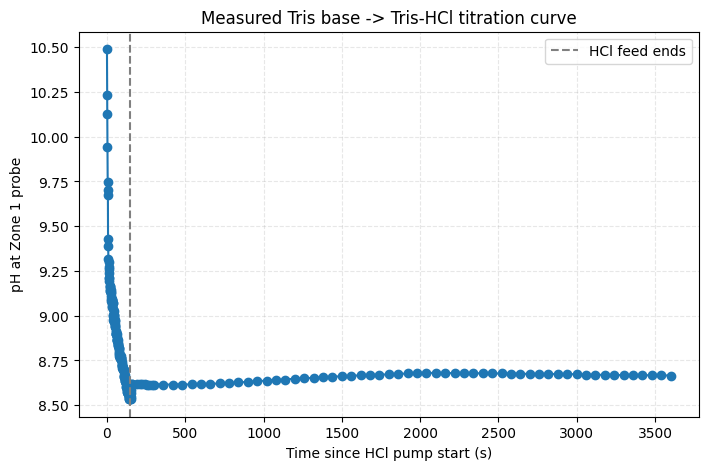

In [3]:
# ==============================================================================
# CELL 2: LOAD MEASURED pH(t) DATA (Zone 1 probe, 12.6 cm from bottom)
# ==============================================================================
# --- Real Measurements ---
t_seconds = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 195, 210, 225, 240, 255, 270, 285, 300, 360, 420, 480, 540, 600, 660, 720, 780, 840, 900, 960, 1020, 1080, 1140, 1200, 1260, 1320, 1380, 1440, 1500, 1560, 1620, 1680, 1740, 1800, 1860, 1920, 1980, 2040, 2100, 2160, 2220, 2280, 2340, 2400, 2460, 2520, 2580, 2640, 2700, 2760, 2820, 2880, 2940, 3000, 3060, 3120, 3180, 3240, 3300, 3360, 3420, 3480, 3540, 3600])
pH_measured = np.array([10.489, 10.231, 10.125, 9.942, 9.746, 9.704, 9.673, 9.429, 9.389, 9.316, 9.300, 9.236, 9.196, 9.213, 9.274, 9.262, 9.208, 9.163, 9.166, 9.158, 9.147, 9.139, 9.140, 9.142, 9.132, 9.128, 9.111, 9.095, 9.083, 9.086, 9.085, 9.092, 9.086, 9.048, 9.052, 9.071, 9.072, 9.069, 9.039, 8.996, 8.973, 9.006, 9.024, 9.005, 8.973, 8.966, 8.999, 9.005, 8.987, 8.973, 8.968, 8.954, 8.942, 8.940, 8.935, 8.907, 8.895, 8.900, 8.916, 8.897, 8.897, 8.897, 8.879, 8.865, 8.867, 8.865, 8.860, 8.862, 8.862, 8.839, 8.829, 8.837, 8.848, 8.837, 8.822, 8.818, 8.813, 8.801, 8.789, 8.785, 8.775, 8.770, 8.777, 8.780, 8.764, 8.763, 8.771, 8.763, 8.754, 8.763, 8.775, 8.766, 8.757, 8.740, 8.730, 8.724, 8.724, 8.717, 8.716, 8.709, 8.707, 8.710, 8.709, 8.700, 8.698, 8.700, 8.698, 8.691, 8.690, 8.670, 8.657, 8.658, 8.665, 8.667, 8.655, 8.644, 8.636, 8.634, 8.637, 8.641, 8.637, 8.623, 8.603, 8.603, 8.616, 8.601, 8.601, 8.589, 8.594, 8.585, 8.573, 8.575, 8.585, 8.580, 8.566, 8.563, 8.566, 8.561, 8.556, 8.549, 8.547, 8.535, 8.533, 8.540, 8.538, 8.538, 8.536, 8.538, 8.538, 8.536, 8.533, 8.535, 8.547, 8.566, 8.587, 8.608, 8.608, 8.611, 8.613, 8.616, 8.618, 8.616, 8.616, 8.616, 8.616, 8.615, 8.615, 8.615, 8.615, 8.615, 8.615, 8.615, 8.616, 8.616, 8.618, 8.622, 8.623, 8.627, 8.630, 8.634, 8.637, 8.641, 8.643, 8.648, 8.650, 8.653, 8.657, 8.658, 8.662, 8.663, 8.667, 8.669, 8.670, 8.672, 8.674, 8.677, 8.679, 8.681, 8.679, 8.679, 8.679, 8.677, 8.679, 8.677, 8.677, 8.677, 8.676, 8.676, 8.674, 8.674, 8.674, 8.674, 8.674, 8.672, 8.670, 8.670, 8.669, 8.669, 8.667, 8.667, 8.667, 8.667, 8.667, 8.665])
# --- end data ---

t_minutes = t_seconds / 60.0

plt.figure(figsize=(8, 5))
plt.plot(t_seconds, pH_measured, 'o-', color='#1f77b4')
plt.axvline(x=t_feed_end_min * 60, color='gray', linestyle='--', label='HCl feed ends')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH at Zone 1 probe')
plt.title('Measured Tris base -> Tris-HCl titration curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


## 3. Forward model: 2-zone reactive mixing + Henderson-Hasselbalch, fit Q

State tracked per zone: moles of Tris and moles of TrisH+ (mass-action exchange at flow `Q` between zones, plus the HCl feed source term in Zone 1 during the feed window). `Q` is the only free parameter - fit by matching predicted Zone-1 pH(t) to your measured curve.

Fitted circulation flow Q : 2.9615 +/- 0.2196 L/min
Flow number Nq            : 0.0439


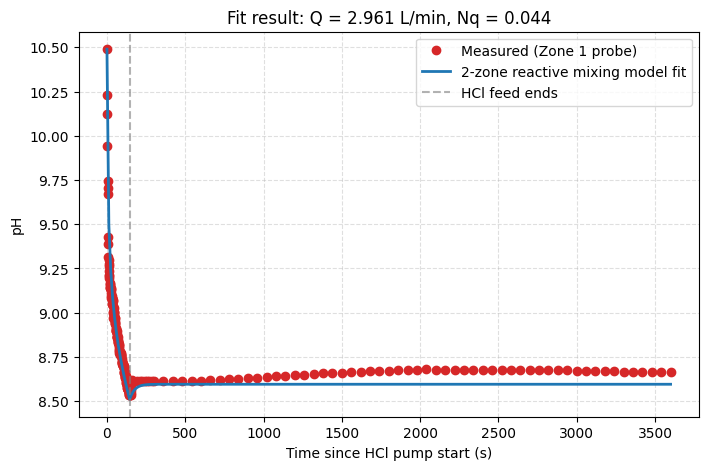

In [4]:
# ==============================================================================
# CELL 3: FORWARD MODEL + FIT Q (THE UNKNOWN CIRCULATION FLOW RATE)
# ==============================================================================
if D_impeller_cm is None or C_Tris_stock_M is None or C_HCl_stock_M is None:
    raise ValueError("Fill in D_impeller_cm, C_Tris_stock_M and C_HCl_stock_M in Cell 1 first.")

pump_rate_L_min = pump_rate_mL_min / 1000.0

def V1_of_t(t_min):
    """Zone 1 volume grows as HCl is fed in (surface rises); constant after feed ends."""
    added = pump_rate_L_min * min(t_min, t_feed_end_min)
    return V1_initial_L + added

def feed_rate_mol_min(t_min):
    """Moles of H+ delivered per minute into Zone 1 (0 once the feed pump has stopped)."""
    if t_min <= t_feed_end_min:
        return pump_rate_L_min * C_HCl_stock_M
    return 0.0

def simulate_moles(Q_L_min, t_eval_min, pH0):
    """Simulate BOTH zones' Tris/TrisH+ moles for a given circulation flow Q (L/min).
    pH0 = the first measured pH point of the specific run being fit (sets the
    initial protonation fraction) - passed explicitly (not read from a global)
    so this same function can be reused for the multi-RPM sweep in Cell 5 and the
    Zone-1/Zone-2/combined reconstruction in Cell 6.
    Returns (n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B, V1_series) arrays."""
    # State vector: [n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B] (moles).
    # Initial protonation fraction is backed out from the FIRST measured pH point
    # (via inverse Henderson-Hasselbalch) rather than assumed to be exactly 0% -
    # using exactly 0% makes the t=0 model pH mathematically infinite (log of a
    # ratio with a zero denominator), and your real starting pH (10.5) implies a
    # tiny but nonzero baseline protonation already present before any HCl is added.
    ratio0 = 10 ** (pH0 - pKa_tris)   # [Tris]/[TrisH+] at t=0
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_stock_M * V1_initial_L
    n_Tris_B_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V_bulk_L
    n_TrisH_B_0 = frac_TrisH_0 * C_Tris_stock_M * V_bulk_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_B_0, n_TrisH_B_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_B, C_TrisH_B = n_Tris_B / V_bulk_L, n_TrisH_B / V_bulk_L

        exch_Tris = Q_L_min * (C_Tris_1 - C_Tris_B)     # Zone1 -> Bulk when positive
        exch_TrisH = Q_L_min * (C_TrisH_1 - C_TrisH_B)

        h_feed = feed_rate_mol_min(t_min)  # instantaneous local neutralization: Tris -> TrisH+

        dn_Tris_1 = -exch_Tris - h_feed
        dn_TrisH_1 = -exch_TrisH + h_feed
        dn_Tris_B = +exch_Tris
        dn_TrisH_B = +exch_TrisH
        return [dn_Tris_1, dn_TrisH_1, dn_Tris_B, dn_TrisH_B]

    # Integrate in two stages (feed ON, then feed OFF) so the solver doesn't have to
    # step across the discontinuity in feed_rate_mol_min at t_feed_end_min.
    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B = Y[0], Y[1], Y[2], Y[3]
    V1_series = np.array([V1_of_t(tm) for tm in t_eval_min])
    return n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B, V1_series

def simulate_ph(Q_L_min, t_eval_min, pH0):
    """Zone-1-only pH(t) - thin wrapper around simulate_moles(), used for fitting."""
    n_Tris_1, n_TrisH_1, _, _, V1_series = simulate_moles(Q_L_min, t_eval_min, pH0)
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    return pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)

def fit_Q(t_sec_arr, pH_arr):
    """Fit the single free parameter Q (L/min) against one (t_seconds, pH) dataset.
    Returns (Q_fit, Q_stderr). Reused by both the single-run analysis below and the
    multi-RPM sweep in Cell 5."""
    pH0 = pH_arr[0]

    def wrapper(t_sec, Q_L_min):
        return simulate_ph(Q_L_min, t_sec / 60.0, pH0)

    Q0_guess = V_total_initial_L * 3.0
    popt, pcov = curve_fit(wrapper, t_sec_arr, pH_arr, p0=[Q0_guess],
                            bounds=([1e-3], [1e4]), maxfev=5000)
    return popt[0], np.sqrt(pcov[0, 0])

def fit_wrapper(t_sec, Q_L_min):
    return simulate_ph(Q_L_min, t_sec / 60.0, pH_measured[0])

Q_fit_L_min, Q_fit_stderr = fit_Q(t_seconds, pH_measured)

print(f"Fitted circulation flow Q : {Q_fit_L_min:.4f} +/- {Q_fit_stderr:.4f} L/min")

D_impeller_m = D_impeller_cm / 100.0
Q_fit_m3_s = Q_fit_L_min / 1000.0 / 60.0
Nq = Q_fit_m3_s / (N_rps * D_impeller_m ** 3)
print(f"Flow number Nq            : {Nq:.4f}")

pH_pred_fit = fit_wrapper(t_seconds, Q_fit_L_min)
t_smooth = np.linspace(t_seconds[0], t_seconds[-1], 300)
pH_pred_smooth = fit_wrapper(t_smooth, Q_fit_L_min)

plt.figure(figsize=(8, 5))
plt.plot(t_seconds, pH_measured, 'o', color='#d62728', label='Measured (Zone 1 probe)')
plt.plot(t_smooth, pH_pred_smooth, '-', color='#1f77b4', linewidth=2, label='2-zone reactive mixing model fit')
plt.axvline(x=t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH')
plt.title(f'Fit result: Q = {Q_fit_L_min:.3f} L/min, Nq = {Nq:.3f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


## 4. Summary & sanity checks

In [5]:
# ==============================================================================
# CELL 4: SUMMARY
# ==============================================================================
print("========================= Nq DETERMINATION SUMMARY =========================")
print(f" Impeller speed N          : {N_rps:.4f} rev/s ({RPM:.0f} RPM)")
print(f" Impeller diameter D       : {D_impeller_cm:.2f} cm")
print(f" Zone 1 volume (initial)   : {V1_initial_L:.3f} L")
print(f" Zone B (bulk) volume      : {V_bulk_L:.3f} L")
print(f" Fitted circulation flow Q : {Q_fit_L_min:.4f} +/- {Q_fit_stderr:.4f} L/min")
print(f" Flow number Nq            : {Nq:.4f}")
try:
    print(f" Re_i (impeller Reynolds)  : {Re_i:,.0f}  ({'turbulent' if Re_i >= 10000 else 'NOT fully turbulent - see Cell 1b'})")
    print(f" Fr_i (Froude number)      : {Fr_i:.4f}  ({'within unbaffled vortex limit' if Fr_i <= Fr_crit_unbaffled else 'ABOVE unbaffled vortex limit - see Cell 1b'})")
    print(f" -> Treat this Nq as {'an approximately constant impeller property near this RPM' if (Re_i >= 10000 and Fr_i <= Fr_crit_unbaffled) else 'an APPARENT/EFFECTIVE value valid only at 450 RPM in this unbaffled geometry'}")
except NameError:
    print(" (Run Cell 1b first for the Re_i / Fr_i validity verdict.)")
print("==============================================================================")
print("\nSanity checks:")
print(" - Typical literature Nq for common impellers (reference only, not ground truth):")
print("     Marine propeller           : ~0.5")
print("     Pitched blade turbine 45   : ~0.5 - 0.87  (you have a 4-blade PBT)")
print("     Rushton (disc) turbine     : ~0.7 - 0.9")
print(" - If the fitted curve (blue) does not visually track the measured points (red) well,")
print("   the single-Q, 2-zone model may be too simple for your system - possible causes:")
print("     * the temperature probe (~30 deg, acts as a pseudo-baffle) changes the flow pattern")
print("       away from the ideal unbaffled assumption used in this model")
print("     * the bulk really needs to be split into 2 sub-zones (as in Kinetika.ipynb's")
print("       3-zone model) rather than lumped into one - harder to identify from a single probe")
print(" - Relative uncertainty on Q (Q_fit_stderr / Q_fit_L_min) above 20-30% suggests the pH(t)")
print("   curve does not strongly constrain Q - consider a faster sampling rate or an earlier")
print("   post-feed sampling window where the curve is still changing quickly.")


========================= Nq DETERMINATION SUMMARY =========================
 Impeller speed N          : 2.6667 rev/s (160 RPM)
 Impeller diameter D       : 7.50 cm
 Zone 1 volume (initial)   : 3.037 L
 Zone B (bulk) volume      : 2.641 L
 Fitted circulation flow Q : 2.9615 +/- 0.2196 L/min
 Flow number Nq            : 0.0439
 Re_i (impeller Reynolds)  : 16,854  (turbulent)
 Fr_i (Froude number)      : 0.0544  (within unbaffled vortex limit)
 -> Treat this Nq as an approximately constant impeller property near this RPM

Sanity checks:
 - Typical literature Nq for common impellers (reference only, not ground truth):
     Marine propeller           : ~0.5
     Pitched blade turbine 45   : ~0.5 - 0.87  (you have a 4-blade PBT)
     Rushton (disc) turbine     : ~0.7 - 0.9
 - If the fitted curve (blue) does not visually track the measured points (red) well,
   the single-Q, 2-zone model may be too simple for your system - possible causes:
     * the temperature probe (~30 deg, acts as a ps

## 6. Reconstruct Zone 1, Zone 2 (bulk), and combined/overall pH

Your probe only measures Zone 1, so the apparent "pH shock" (pH drops, looks
stable, then suddenly rises) is a **local Zone 1 artifact**, not a global
system event. The fitted 2-zone model already tracks the (unmeasured) bulk
state internally - this cell exposes it:

- **Zone 1 pH** - what your probe actually reads (matches the measured curve)
- **Zone (Bulk) pH** - reconstructed from the model; expected to lag behind
  and be less extreme than Zone 1 (it doesn't see the feed directly, only
  receives it via the slower Q exchange)
- **Combined/overall pH** - what a perfectly-mixed whole-tank reading would
  show at each instant (computed from TOTAL Tris/TrisH+ moles across both
  zones); this is the smooth "true average" trajectory the local Zone 1
  overshoot/rebound is oscillating around.

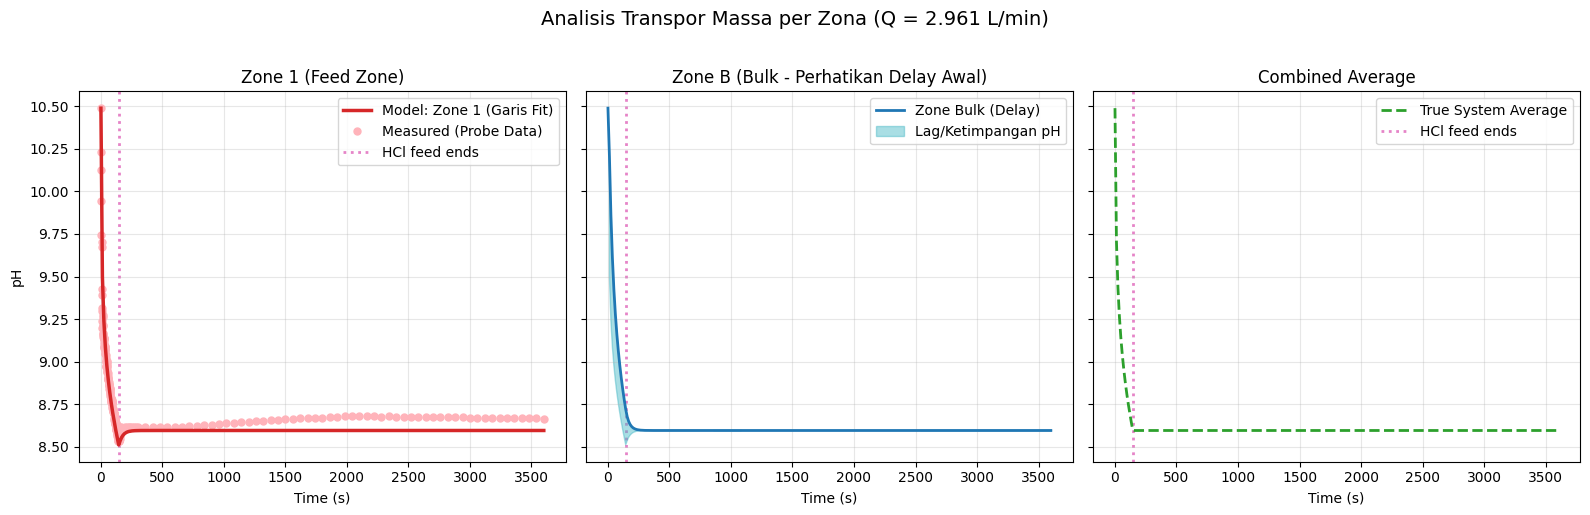

Pada detik ke-60 titrasi:
 -> pH Zone 1 telah turun ke : 8.890
 -> pH Zone Bulk baru turun ke: 9.280
 -> Terbukti ada 'Lag/Jeda' antar zona sebesar: 0.390 unit pH


In [25]:
# ==============================================================================
# CELL 6: ZOOMED-IN VIEW UNTUK COGNITIVE CHECK (JEDA WAKTU ZONA 1 VS BULK)
# ==============================================================================
n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B, V1_series = simulate_moles(Q_fit_L_min, t_smooth / 60.0, pH_measured[0])

C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
pH_zone1 = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)

C_Tris_B = np.maximum(n_Tris_B, 1e-12) / V_bulk_L
C_TrisH_B = np.maximum(n_TrisH_B, 1e-12) / V_bulk_L
pH_zoneB = pKa_tris + np.log10(C_Tris_B / C_TrisH_B)

n_Tris_total = n_Tris_1 + n_Tris_B
n_TrisH_total = n_TrisH_1 + n_TrisH_B
pH_combined = pKa_tris + np.log10(np.maximum(n_Tris_total, 1e-12) / np.maximum(n_TrisH_total, 1e-12))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(f'Analisis Transpor Massa per Zona (Q = {Q_fit_L_min:.3f} L/min)', fontsize=14, y=1.02)

# PANEL 1: ZONE 1
axes[0].plot(t_smooth, pH_zone1, '-', color='#d62728', linewidth=2.5, label='Model: Zone 1 (Garis Fit)', zorder=3)
axes[0].plot(t_seconds, pH_measured, 'o', color='#ffb3ba', markersize=5, label='Measured (Probe Data)', zorder=2)
axes[0].axvline(x=t_feed_end_min * 60, color='#e377c2', linestyle=':', alpha=0.9, linewidth=2, label='HCl feed ends', zorder=1)
axes[0].set_title('Zone 1 (Feed Zone)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('pH')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3, zorder=0)

# PANEL 2: ZONE B (BULK)
axes[1].plot(t_smooth, pH_zoneB, '-', color='#1f77b4', linewidth=2, label='Zone Bulk (Delay)', zorder=3)
axes[1].axvline(x=t_feed_end_min * 60, color='#e377c2', linestyle=':', alpha=0.9, linewidth=2, zorder=1)
# Mengubah warna fill_between ke warna biru medium cerah (#41b6c4) dengan alpha=0.45 agar jeda waktu terlihat tegas
axes[1].fill_between(t_smooth, pH_zone1, pH_zoneB, where=(pH_zone1 < pH_zoneB), color='#41b6c4', alpha=0.45, label='Lag/Ketimpangan pH', zorder=1)
axes[1].set_title('Zone B (Bulk - Perhatikan Delay Awal)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3, zorder=0)

# PANEL 3: COMBINED / OVERALL
axes[2].plot(t_smooth, pH_combined, '--', color='#2ca02c', linewidth=2, label='True System Average', zorder=3)
axes[2].axvline(x=t_feed_end_min * 60, color='#e377c2', linestyle=':', alpha=0.9, linewidth=2, label='HCl feed ends', zorder=1)
axes[2].set_title('Combined Average')
axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

# Evaluasi delta pH awal (detik ke-60)
idx_6s = np.abs(t_smooth - 60).argmin()
delta_pH_6s = pH_zoneB[idx_6s] - pH_zone1[idx_6s]
print(f"Pada detik ke-60 titrasi:")
print(f" -> pH Zone 1 telah turun ke : {pH_zone1[idx_6s]:.3f}")
print(f" -> pH Zone Bulk baru turun ke: {pH_zoneB[idx_6s]:.3f}")
print(f" -> Terbukti ada 'Lag/Jeda' antar zona sebesar: {delta_pH_6s:.3f} unit pH")

## 7. What Q (and RPM) would eliminate the pH shock?

Scans a range of circulation flows Q and computes the Zone 1 "shock" amplitude
the model predicts at each one, using the SAME feed profile and geometry as
your real run (only Q is varied). As Q increases, Zone 1 mixes with the bulk
fast enough that it can no longer get locally over-acidified - the shock
should shrink toward zero. This identifies the minimum Q (and, if you provide
your own (RPM, Nq) points below, an estimated RPM) needed to avoid it -
entirely from your existing data, no new experiment required.

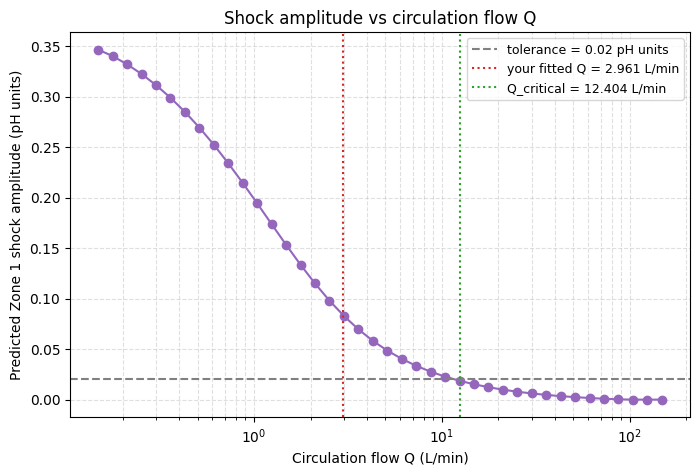

Your current run: Q = 2.9615 L/min -> predicted shock = 0.0841 pH units
Estimated Q needed to bring the shock below 0.02 pH units: 12.4039 L/min (~4.19x your current circulation flow)
Q_critical (12.40 L/min) is OUTSIDE the range you've actually tested (2.96 - 5.07 L/min at 160-450 RPM).
No RPM estimate is reported here on purpose: extrapolating beyond tested data would
require assuming how Nq continues to behave outside the tested range, and Cell 1b/5
already showed Nq DECREASES with RPM here (vortexing) - so higher RPM is not guaranteed
to raise Q further, and may even make it worse. Increasing RPM within the untested
range is not a reliable way to reach this Q_critical based on the data you have.


In [26]:
# ==============================================================================
# CELL 7: CRITICAL Q (AND ESTIMATED RPM) TO ELIMINATE THE pH SHOCK
# ==============================================================================
def shock_amplitude(Q_L_min, t_eval_min, pH0):
    n_Tris_1, n_TrisH_1, _, _, V1_series = simulate_moles(Q_L_min, t_eval_min, pH0)
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    pH_z1 = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    return pH_z1[-1] - np.min(pH_z1)   # final pH minus the local dip -> 0 once there's no more overshoot

t_scan_min = np.linspace(0, t_seconds[-1], 400) / 60.0
Q_scan = np.geomspace(max(Q_fit_L_min / 20, 1e-3), Q_fit_L_min * 50, 40)
shocks = np.array([shock_amplitude(Q, t_scan_min, pH_measured[0]) for Q in Q_scan])

SHOCK_TOLERANCE_PH = 0.02   # "no meaningful shock" threshold - adjust to your required precision
below_tol = np.where(shocks <= SHOCK_TOLERANCE_PH)[0]
Q_critical = Q_scan[below_tol[0]] if len(below_tol) > 0 else None

plt.figure(figsize=(8, 5))
plt.semilogx(Q_scan, shocks, 'o-', color='#9467bd')
plt.axhline(y=SHOCK_TOLERANCE_PH, color='gray', linestyle='--', label=f'tolerance = {SHOCK_TOLERANCE_PH} pH units')
plt.axvline(x=Q_fit_L_min, color='#d62728', linestyle=':', label=f'your fitted Q = {Q_fit_L_min:.3f} L/min')
if Q_critical is not None:
    plt.axvline(x=Q_critical, color='#2ca02c', linestyle=':', label=f'Q_critical = {Q_critical:.3f} L/min')
plt.xlabel('Circulation flow Q (L/min)')
plt.ylabel('Predicted Zone 1 shock amplitude (pH units)')
plt.title('Shock amplitude vs circulation flow Q')
plt.legend(fontsize=9)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

print(f"Your current run: Q = {Q_fit_L_min:.4f} L/min -> predicted shock = {shock_amplitude(Q_fit_L_min, t_scan_min, pH_measured[0]):.4f} pH units")
if Q_critical is not None:
    factor = Q_critical / Q_fit_L_min
    print(f"Estimated Q needed to bring the shock below {SHOCK_TOLERANCE_PH} pH units: {Q_critical:.4f} L/min "
          f"(~{factor:.2f}x your current circulation flow)")

    # --- OPTIONAL: convert Q_critical to an estimated RPM ---
    # Fill in your own (RPM, Nq) data points from runs you've already done (e.g. 160 and 450 RPM)
    # to interpolate/extrapolate what RPM might reach Q_critical. With only 2-3 points this is a
    # rough estimate, not a guarantee - especially since Nq is RPM-dependent here (Cell 1b/5), so
    # do not extrapolate far beyond the RPM range you've actually tested.
    known_rpm_Nq = {
        160: 0.0439,   # <-- FILL IN: Nq you obtained at 160 RPM
        450: 0.0267,   # from your 450 RPM run
    }
    known_rpm_Nq = {k: v for k, v in known_rpm_Nq.items() if v is not None}
    if len(known_rpm_Nq) >= 2:
        rpms_known = np.array(sorted(known_rpm_Nq.keys()))
        Qs_known = np.array([known_rpm_Nq[r] * (r / 60.0) * D_impeller_m ** 3 * 1000 * 60 for r in rpms_known])  # L/min

        if Q_critical > Qs_known.max() or Q_critical < Qs_known.min():
            # np.interp CANNOT extrapolate - outside the known range it silently clamps to the
            # nearest endpoint, which looks like a real answer but isn't one. Report this honestly
            # instead of printing a fabricated RPM.
            print(f"Q_critical ({Q_critical:.2f} L/min) is OUTSIDE the range you've actually tested "
                  f"({Qs_known.min():.2f} - {Qs_known.max():.2f} L/min at {rpms_known.min():.0f}-{rpms_known.max():.0f} RPM).")
            print("No RPM estimate is reported here on purpose: extrapolating beyond tested data would")
            print("require assuming how Nq continues to behave outside the tested range, and Cell 1b/5")
            print("already showed Nq DECREASES with RPM here (vortexing) - so higher RPM is not guaranteed")
            print("to raise Q further, and may even make it worse. Increasing RPM within the untested")
            print("range is not a reliable way to reach this Q_critical based on the data you have.")
        else:
            # simple log-log interpolation (power-law Q ~ RPM^a between your known points) - only
            # valid because Q_critical falls between two points you actually measured.
            logQ_of_logRPM = np.interp(np.log(Q_critical), np.log(Qs_known), np.log(rpms_known))
            RPM_estimate = np.exp(logQ_of_logRPM)
            print(f"Rough RPM estimate for Q_critical (interpolated between your known (RPM, Nq) points): ~{RPM_estimate:.0f} RPM")
    else:
        print("Fill in known_rpm_Nq with at least 2 (RPM, Nq) points above to get an RPM estimate for Q_critical.")
else:
    print(f"No Q in the scanned range brought the shock below {SHOCK_TOLERANCE_PH} pH units - widen Q_scan's upper bound.")


## 8. Alternative lever: slow down the HCl feed pump (no RPM/hardware change needed)

Cell 7 showed that raising RPM alone - even up to the maximum "safe" (non-vortex)
RPM for this impeller - is unlikely to reach `Q_critical`. Since your actual
circulation flow Q is essentially fixed by hardware/RPM limits already tested,
a more immediately actionable lever is the **HCl pump speed itself**: slowing
the feed gives Zone 1 more time to exchange with the Bulk in real time while
acid is still being added, instead of a fast burst of acid arriving faster
than it can be shared. This scans the pump rate (holding your ACTUAL measured
Q fixed) to find how slow the feed needs to be to eliminate the shock without
touching RPM at all.

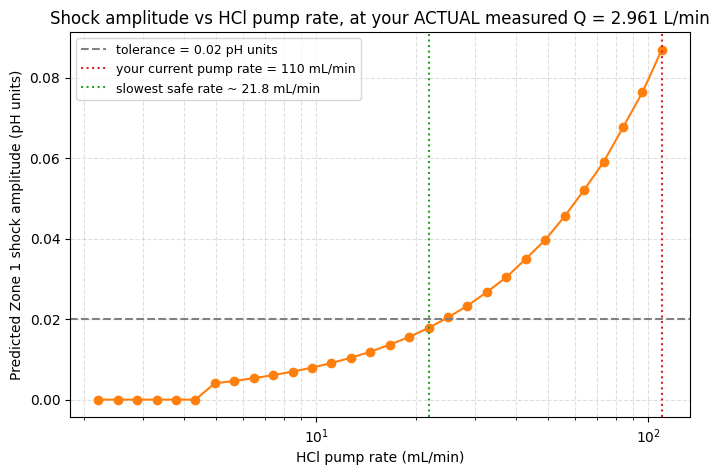

At your current circulation flow (Q = 2.961 L/min, no RPM/hardware change),
slowing the HCl pump to ~21.8 mL/min (from 110 mL/min) is predicted
to bring the pH shock below 0.02 pH units.
New feed duration at that rate: 12.2 min (vs 2.4 min currently).


In [8]:
# ==============================================================================
# CELL 8: CAN A SLOWER HCl PUMP RATE ELIMINATE THE SHOCK AT YOUR CURRENT Q?
# ==============================================================================
def simulate_moles_custom_feed(Q_L_min, pump_rate_L_min_custom, t_eval_min, pH0):
    """Same 2-zone reactive mixing model as simulate_moles(), but with the HCl
    pump rate as an explicit parameter instead of the fixed value from Cell 1
    (feed duration is recomputed so the SAME total 266 mL of HCl is still
    delivered, just slower)."""
    t_feed_end_custom = (V_HCl_total_mL / 1000.0) / pump_rate_L_min_custom

    def V1_of_t_custom(t_min):
        return V1_initial_L + pump_rate_L_min_custom * min(t_min, t_feed_end_custom)

    def feed_rate_custom(t_min):
        return pump_rate_L_min_custom * C_HCl_stock_M if t_min <= t_feed_end_custom else 0.0

    ratio0 = 10 ** (pH0 - pKa_tris)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    y0 = [(1 - frac_TrisH_0) * C_Tris_stock_M * V1_initial_L,
          frac_TrisH_0 * C_Tris_stock_M * V1_initial_L,
          (1 - frac_TrisH_0) * C_Tris_stock_M * V_bulk_L,
          frac_TrisH_0 * C_Tris_stock_M * V_bulk_L]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_B, n_TrisH_B = np.maximum(y, 0.0)
        V1 = V1_of_t_custom(t_min)
        exch_Tris = Q_L_min * (n_Tris_1 / V1 - n_Tris_B / V_bulk_L)
        exch_TrisH = Q_L_min * (n_TrisH_1 / V1 - n_TrisH_B / V_bulk_L)
        h_feed = feed_rate_custom(t_min)
        return [-exch_Tris - h_feed, -exch_TrisH + h_feed, exch_Tris, exch_TrisH]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_custom:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_custom
        sol1 = solve_ivp(ode, (0, t_feed_end_custom), y0, t_eval=t_eval_min[mask1], method='BDF', rtol=1e-7, atol=1e-10)
        sol2 = solve_ivp(ode, (t_feed_end_custom, t_end), sol1.y[:, -1], t_eval=t_eval_min[~mask1], method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y, sol2.y])

    V1_series = np.array([V1_of_t_custom(tm) for tm in t_eval_min])
    C_Tris_1 = np.maximum(Y[0], 1e-12) / V1_series
    C_TrisH_1 = np.maximum(Y[1], 1e-12) / V1_series
    pH_z1 = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    return pH_z1[-1] - np.min(pH_z1)  # shock amplitude for this pump rate

# Scan over a much longer observation window so slower feeds have time to fully play out
t_scan_long_min = np.linspace(0, max(t_seconds[-1], 3600), 500) / 60.0
pump_rates_scan = np.geomspace(pump_rate_mL_min / 50, pump_rate_mL_min, 30)  # down to 1/50th of your current 110 mL/min
shocks_pump = np.array([simulate_moles_custom_feed(Q_fit_L_min, pr / 1000.0, t_scan_long_min, pH_measured[0])
                         for pr in pump_rates_scan])

below_tol_pump = np.where(shocks_pump <= SHOCK_TOLERANCE_PH)[0]
pump_critical = pump_rates_scan[below_tol_pump[-1]] if len(below_tol_pump) > 0 else None
# (largest pump rate - i.e. least slow-down needed - that still keeps the shock below tolerance)

plt.figure(figsize=(8, 5))
plt.semilogx(pump_rates_scan, shocks_pump, 'o-', color='#ff7f0e')
plt.axhline(y=SHOCK_TOLERANCE_PH, color='gray', linestyle='--', label=f'tolerance = {SHOCK_TOLERANCE_PH} pH units')
plt.axvline(x=pump_rate_mL_min, color='#d62728', linestyle=':', label=f'your current pump rate = {pump_rate_mL_min:.0f} mL/min')
if pump_critical is not None:
    plt.axvline(x=pump_critical, color='#2ca02c', linestyle=':', label=f'slowest safe rate ~ {pump_critical:.1f} mL/min')
plt.xlabel('HCl pump rate (mL/min)')
plt.ylabel('Predicted Zone 1 shock amplitude (pH units)')
plt.title(f'Shock amplitude vs HCl pump rate, at your ACTUAL measured Q = {Q_fit_L_min:.3f} L/min')
plt.legend(fontsize=9)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

if pump_critical is not None:
    print(f"At your current circulation flow (Q = {Q_fit_L_min:.3f} L/min, no RPM/hardware change),")
    print(f"slowing the HCl pump to ~{pump_critical:.1f} mL/min (from {pump_rate_mL_min:.0f} mL/min) is predicted")
    print(f"to bring the pH shock below {SHOCK_TOLERANCE_PH} pH units.")
    print(f"New feed duration at that rate: {(V_HCl_total_mL/pump_critical):.1f} min (vs {t_feed_end_min:.1f} min currently).")
else:
    print(f"Even the slowest pump rate scanned ({pump_rates_scan[0]:.2f} mL/min) did not bring the shock below "
          f"{SHOCK_TOLERANCE_PH} pH units at your current Q - this lever alone may not be enough; Q itself likely")
    print("needs to increase too (bigger impeller diameter or adding true baffles to safely allow higher RPM).")


## 5. Multi-RPM sweep: does Nq actually stay constant?

Repeat the same titration at several different RPM settings (same reactor,
same Tris/HCl concentrations - only RPM changes between runs). Because the
Fr_i check in Cell 1b flagged that 450 RPM is above the unbaffled vortex
ceiling, Nq is expected to be RPM-dependent here rather than a true constant -
this section fits Q independently for each RPM run and plots Nq vs RPM (and vs
Fr_i) so you can see the actual trend instead of assuming one fixed number.

Replace the placeholder entries in `rpm_experiments` below with your real
per-RPM (t_seconds, pH_measured) datasets.

RPM= 160  N=2.667 rev/s  Q=  2.9615 +/- 0.2196 L/min  Nq=0.0439  Re_i=16,854  Fr_i=0.054
RPM= 450  N=7.500 rev/s  Q=  5.0595 +/- 0.3917 L/min  Nq=0.0267  Re_i=47,402  Fr_i=0.430


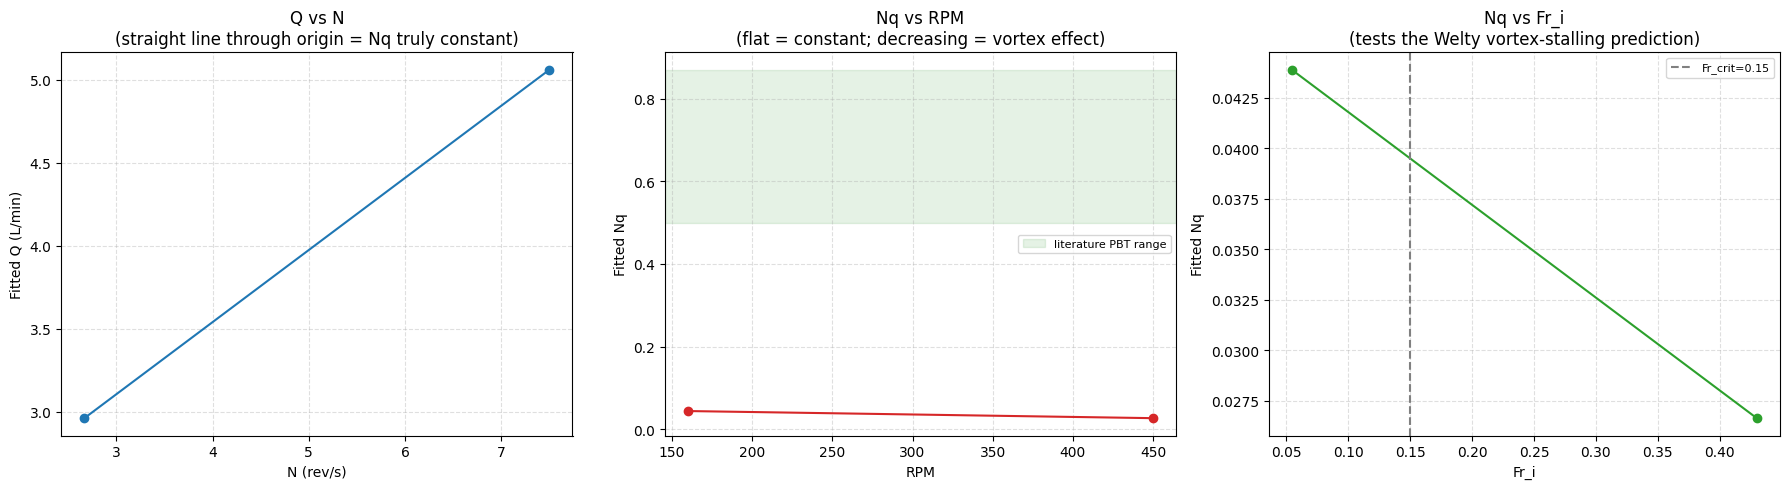


Nq range across the sweep: 0.0267 to 0.0439  (spread = 48.8% of the mean)
-> Nq changes MEANINGFULLY with RPM: treat it as RPM-dependent (as the Fr_i check predicted),
   not as a single fixed impeller constant, in this unbaffled geometry.


In [9]:
# ==============================================================================
# CELL 5: MULTI-RPM SWEEP - Nq(RPM) INSTEAD OF A SINGLE VALUE
# ==============================================================================
if D_impeller_cm is None or C_Tris_stock_M is None or C_HCl_stock_M is None:
    raise ValueError("Fill in D_impeller_cm, C_Tris_stock_M and C_HCl_stock_M in Cell 1 first.")

# Same reactor/reagents, only RPM + the resulting pH(t) curve differ per entry.
rpm_experiments = {
    450: (np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142]),
          np.array([10.559, 10.375, 10.268, 9.775, 9.794, 9.804, 9.699, 9.663, 9.584, 9.55, 9.408, 9.376, 9.388, 9.4, 9.377, 9.369, 9.353, 9.312, 9.296, 9.269, 9.234, 9.193, 9.191, 9.193, 9.2, 9.203, 9.196, 9.184, 9.165, 9.167, 9.133, 9.133, 9.112, 9.105, 9.095, 9.086, 9.1, 9.096, 9.064, 9.059, 9.047, 9.052, 9.048, 9.041, 9.034, 9.024, 9.014, 9.009, 9.019, 9.029, 9.028, 9.026, 9.014, 8.988, 8.991, 8.981, 8.974, 8.962, 8.959, 8.945, 8.933, 8.928, 8.936, 8.94, 8.935, 8.926, 8.91, 8.9, 8.897, 8.893, 8.895, 8.883, 8.879, 8.869, 8.878, 8.866, 8.8454, 8.842, 8.857, 8.852, 8.836, 8.842, 8.843, 8.84, 8.843, 8.829, 8.831, 8.826, 8.798, 8.811, 8.807, 8.807, 8.79, 8.798, 8.795, 8.785, 8.778, 8.773, 8.776, 8.773, 8.767, 8.752, 8.755, 8.769, 8.762, 8.747, 8.738, 8.742, 8.745, 8.73, 8.721, 8.717, 8.716, 8.704, 8.7, 8.7, 8.705, 8.693, 8.683, 8.688, 8.681, 8.673, 8.668, 8.673, 8.674, 8.668, 8.654, 8.655, 8.654, 8.65, 8.637, 8.642, 8.655, 8.642, 8.631, 8.63, 8.654, 8.673, 8.686, 8.685, 8.686, 8.686, 8.685])),
    160: (t_seconds, pH_measured),
}
# --- end example data ---

sweep_results = []
for RPM_i, (t_sec_i, pH_i) in sorted(rpm_experiments.items()):
    N_rps_i = RPM_i / 60.0
    Q_i, Q_stderr_i = fit_Q(t_sec_i, pH_i)
    Q_i_m3s = Q_i / 1000.0 / 60.0
    Nq_i = Q_i_m3s / (N_rps_i * D_impeller_m ** 3)
    Re_i_i = rho_kg_m3 * N_rps_i * D_impeller_m ** 2 / mu_Pa_s
    Fr_i_i = N_rps_i ** 2 * D_impeller_m / g
    sweep_results.append(dict(RPM=RPM_i, N_rps=N_rps_i, Q_L_min=Q_i, Q_stderr=Q_stderr_i,
                               Nq=Nq_i, Re_i=Re_i_i, Fr_i=Fr_i_i))
    print(f"RPM={RPM_i:>4.0f}  N={N_rps_i:.3f} rev/s  Q={Q_i:8.4f} +/- {Q_stderr_i:.4f} L/min  "
          f"Nq={Nq_i:.4f}  Re_i={Re_i_i:,.0f}  Fr_i={Fr_i_i:.3f}")

rpms = [r['RPM'] for r in sweep_results]
Ns = [r['N_rps'] for r in sweep_results]
Qs = [r['Q_L_min'] for r in sweep_results]
Nqs = [r['Nq'] for r in sweep_results]
Fris = [r['Fr_i'] for r in sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(Ns, Qs, 'o-', color='#1f77b4')
axes[0].set_xlabel('N (rev/s)'); axes[0].set_ylabel('Fitted Q (L/min)')
axes[0].set_title('Q vs N\n(straight line through origin = Nq truly constant)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(rpms, Nqs, 'o-', color='#d62728')
axes[1].axhspan(0.5, 0.87, color='green', alpha=0.1, label='literature PBT range')
axes[1].set_xlabel('RPM'); axes[1].set_ylabel('Fitted Nq')
axes[1].set_title('Nq vs RPM\n(flat = constant; decreasing = vortex effect)')
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].plot(Fris, Nqs, 'o-', color='#2ca02c')
axes[2].axvline(x=Fr_crit_unbaffled, color='gray', linestyle='--', label=f'Fr_crit={Fr_crit_unbaffled}')
axes[2].set_xlabel('Fr_i'); axes[2].set_ylabel('Fitted Nq')
axes[2].set_title('Nq vs Fr_i\n(tests the Welty vortex-stalling prediction)')
axes[2].legend(fontsize=8)
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

nq_range = max(Nqs) - min(Nqs)
nq_mean = np.mean(Nqs)
print(f"\nNq range across the sweep: {min(Nqs):.4f} to {max(Nqs):.4f}  (spread = {nq_range/nq_mean*100:.1f}% of the mean)")
if nq_range / nq_mean > 0.15:
    print("-> Nq changes MEANINGFULLY with RPM: treat it as RPM-dependent (as the Fr_i check predicted),")
    print("   not as a single fixed impeller constant, in this unbaffled geometry.")
else:
    print("-> Nq is roughly constant across this RPM range - safe to treat as a fixed impeller property here.")
